<a href="https://colab.research.google.com/github/cocyten27/MODULE_6/blob/main/M6_L06_schedulers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAE-IA · Module 6 · L06 — Schedulers, Speed, and Memory Optimization

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L06 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L01–L05 completed |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Swap schedulers on a loaded pipeline and explain the quality/speed trade-off of each
- [ ] Measure peak VRAM usage before and after enabling attention slicing
- [ ] Load LCM-LoRA and generate images in 4 steps with correct CFG settings
- [ ] Choose the right scheduler and step count for a given latency budget

## Before you start
- L01-L05 completed
- T4 GPU runtime selected (`Runtime > Change runtime type > T4 GPU`)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed, and logs in to HuggingFace.

In [ ]:
# ================================================================
# TAE-IA M6 · Configuración Estándar -- NO MODIFICAR ESTA CELDA
# ================================================================
import os, sys, random, time, shutil # Importa módulos necesarios para operaciones de sistema, aleatorias, tiempo y archivos.
import numpy as np # Importa numpy para operaciones numéricas.

from google.colab import drive # Importa drive desde google.colab para montar Google Drive.
drive.mount('/content/drive') # Monta Google Drive en el directorio '/content/drive'.

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'   # persistente, sobrevive a las sesiones # Define la ruta del caché de modelos en Google Drive.
LOCAL_CACHE = '/content/model_cache'                      # efímero, muere con el tiempo de ejecución # Define la ruta del caché de modelos en el disco local del entorno de ejecución.
os.makedirs(MODEL_CACHE, exist_ok=True) # Crea el directorio del caché de modelos en Drive si no existe.
os.makedirs(LOCAL_CACHE, exist_ok=True) # Crea el directorio del caché de modelos local si no existe.

# Limpia cualquier caché dejado por versiones anteriores del curso.
for _leftover in ('hub', 'xet'): # Itera sobre los elementos 'hub' y 'xet'.
    _p = os.path.join(MODEL_CACHE, _leftover) # Construye la ruta completa para el elemento en el caché de Drive.
    if os.path.exists(_p): # Verifica si la ruta existe.
        shutil.rmtree(_p) # Si existe, elimina el directorio y su contenido.

# ----------------------------------------------------------------
# Caché de modelos con fallback automático
# ----------------------------------------------------------------
# Los modelos se almacenan en caché en Drive para que sobrevivan a un reinicio de sesión.
# Una cuenta gratuita de Google solo tiene 15 GB, compartidos con Gmail y Fotos,
# lo cual es menos de lo que este curso necesita de principio a fin.
# Así que cuando Drive no tiene espacio, almacenamos en caché en el propio disco del tiempo de ejecución:
# el laboratorio aún funciona, pero esa copia se elimina cuando termina la sesión.
#
# La elección se hace por modelo, no una vez por notebook. Un modelo que ya está
# en Drive sigue siendo leído de Drive incluso cuando Drive está demasiado lleno
# para aceptar algo nuevo.

DRIVE_HEADROOM_GB = 1.0    # nunca llenar Drive hasta el último byte # Define el espacio libre mínimo en Drive en GB.
SIZE_MARGIN       = 1.15   # archivos temporales y metadatos escritos durante una descarga # Margen de tamaño para descargas en GB.


def _free_gb(path): # Define una función para obtener el espacio libre en GB de una ruta.
    try: # Intenta ejecutar el siguiente bloque de código.
        return shutil.disk_usage(path).free / 1e9 # Retorna el espacio libre en GB.
    except Exception: # Captura cualquier excepción.
        return 0.0 # Si ocurre un error, retorna 0.0 GB.


def _is_cached(path): # Define una función para verificar si un modelo está en caché.
    """True si <path> contiene algo que no sea la carpeta de descarga incompleta de HuggingFace."""
    return os.path.isdir(path) and any(e != '.cache' for e in os.listdir(path)) # Retorna True si la ruta es un directorio y no está vacía o solo contiene '.cache'.


def _disk_full(exc): # Define una función para verificar si un error es debido a disco lleno.
    """ENOSPC, cuota excedida, o el error de E/S que drivefs genera cuando Drive está lleno."""
    return (getattr(exc, 'errno', None) in (28, 122, 5) # Comprueba si el código de error es de espacio en disco.
            or 'no space' in str(exc).lower() # Comprueba si el mensaje de error contiene 'no space'.
            or 'quota' in str(exc).lower()) # Comprueba si el mensaje de error contiene 'quota'.


def cache_dir(name, needed_gb): # Define una función para determinar el directorio de caché de un modelo.
    """Retorna el directorio donde el modelo <name> debería vivir, prefiriendo Drive."""
    drive_dir = os.path.join(MODEL_CACHE, name) # Construye la ruta en Drive.
    local_dir = os.path.join(LOCAL_CACHE, name) # Construye la ruta en el caché local.

    if _is_cached(drive_dir): # Si el modelo ya está en caché en Drive.
        return drive_dir            # ya en Drive: leerlo no cuesta espacio # Retorna la ruta de Drive.
    if _is_cached(local_dir): # Si el modelo ya está en caché local.
        return local_dir            # ya se recurrió a este durante esta sesión # Retorna la ruta local.

    required = needed_gb * SIZE_MARGIN + DRIVE_HEADROOM_GB # Calcula el espacio requerido.
    free = _free_gb(MODEL_CACHE) # Obtiene el espacio libre en Drive.
    if free >= required: # Si hay suficiente espacio en Drive.
        os.makedirs(drive_dir, exist_ok=True) # Crea el directorio en Drive si no existe.
        print(f'[cache] {name} -> Drive ({needed_gb:.2f} GB necesarios, {free:.1f} GB libres).') # Imprime mensaje informativo.
        return drive_dir # Retorna la ruta de Drive.

    local_free = _free_gb('/content') # Obtiene el espacio libre en el disco local.
    if local_free < required: # Si no hay suficiente espacio ni en Drive ni localmente.
        raise RuntimeError( # Lanza una excepción.
            f'{name} necesita ~{needed_gb:.1f} GB, pero solo {free:.1f} GB están libres en ' # Mensaje de error.
            f'Drive y {local_free:.1f} GB en el disco del tiempo de ejecución.\n' # Continúa el mensaje de error.
            f'Libere espacio en Google Drive (elimine subcarpetas no utilizadas de TAE_IA_M6/models) ' # Sugerencia de solución.
            f'y vuelva a ejecutar esta celda.') # Continúa la sugerencia de solución.

    os.makedirs(local_dir, exist_ok=True) # Crea el directorio en el caché local si no existe.
    print(f'[cache] No hay suficiente espacio en Drive para {name}: necesita {needed_gb:.2f} GB\n' # Imprime mensaje informativo.
          f'        más margen, {free:.1f} GB libres. Almacenando en caché en el tiempo de ejecución en su lugar.\n' # Continúa el mensaje.
          f'        El laboratorio funciona normalmente, pero esta copia se elimina cuando termina la sesión\n' # Continúa el mensaje.
          f'        y se descarga de nuevo la próxima vez. Libere espacio en Drive para evitar\n' # Continúa el mensaje.
          f'        la descarga repetida.') # Continúa el mensaje.
    return local_dir # Retorna la ruta local.


def cached_fetch(name, needed_gb, download): # Define una función para descargar y almacenar en caché.
    """Ejecuta download(target_dir) en el mejor caché disponible y retorna su resultado.

    Reintenta en el disco del tiempo de ejecución si Drive se llena a mitad de la descarga:
    una verificación de espacio previa no puede detectar una cuota que se agota a mitad de camino.
    """
    target = cache_dir(name, needed_gb) # Determina el directorio de caché objetivo.
    try: # Intenta ejecutar el siguiente bloque de código.
        return download(target) # Ejecuta la función de descarga en el directorio objetivo.
    except OSError as e: # Captura errores de sistema de archivos.
        if not _disk_full(e) or target.startswith(LOCAL_CACHE): # Si el error no es por disco lleno o ya está en caché local.
            raise # Lanza la excepción.
        print(f'[cache] Drive se quedó sin espacio a mitad de la descarga ({e}).\n' # Imprime mensaje de error.
              f'        Descartando la copia parcial y reintentando en el disco del tiempo de ejecución.') # Continúa el mensaje.
        shutil.rmtree(target, ignore_errors=True) # Elimina la copia parcial en Drive.
        fallback = os.path.join(LOCAL_CACHE, name) # Define la ruta de fallback en el caché local.
        os.makedirs(fallback, exist_ok=True) # Crea el directorio de fallback si no existe.
        return download(fallback) # Reintenta la descarga en el caché local.


def cached_snapshot(name, repo_id, needed_gb, **kwargs): # Define una función para descargar un snapshot de HuggingFace.
    """snapshot_download en el mejor caché disponible, retornando su ruta."""
    from huggingface_hub import snapshot_download # Importa snapshot_download desde huggingface_hub.

    def _dl(target): # Define una función interna de descarga.
        snapshot_download(repo_id, local_dir=target, **kwargs) # Descarga el snapshot.
        return target # Retorna la ruta de descarga.

    return cached_fetch(name, needed_gb, _dl) # Llama a cached_fetch para manejar la descarga con caché.


_drive_free = _free_gb(MODEL_CACHE) # Obtiene el espacio libre en Drive.
print(f'Caché de modelos: {MODEL_CACHE}  ({_drive_free:.1f} GB libres en Drive)') # Imprime información del caché de modelos.
if _drive_free < 1.0: # Si hay menos de 1 GB libre en Drive.
    print('ADVERTENCIA: menos de 1 GB libre en Drive. Los modelos se almacenarán en caché en el tiempo de ejecución,\n'
          '         pero guardar las salidas de su laboratorio puede fallar. Libere espacio en Drive.') # Imprime una advertencia.

import torch # Importa PyTorch.
if not torch.cuda.is_available(): # Si CUDA no está disponible (no hay GPU).
    print('\nNo se detectó GPU. Vaya a: Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU') # Imprime un mensaje de error.
    raise SystemExit('GPU requerida.') # Sale del programa porque se requiere GPU.

gpu_name = torch.cuda.get_device_name(0) # Obtiene el nombre de la GPU.
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9 # Obtiene la VRAM total de la GPU en GB.
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB') # Imprime información de la GPU.

SEED = 42 # Define la semilla aleatoria.
random.seed(SEED); np.random.seed(SEED) # Fija la semilla para los generadores de números aleatorios de Python y NumPy.
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED) # Fija la semilla para los generadores de números aleatorios de PyTorch (CPU y GPU).
print(f'Semilla fijada: {SEED}') # Imprime la semilla fijada.
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}') # Imprime las versiones de Python y PyTorch.

# Inicio de sesión en HuggingFace -- necesario en cada nueva sesión de Colab
import huggingface_hub # Importa huggingface_hub para interactuar con el Hub de Hugging Face.

try: # Intenta obtener el token de Hugging Face.
    _token = huggingface_hub.get_token() # Obtiene el token de autenticación de Hugging Face.
except Exception: # Captura cualquier excepción que pueda ocurrir si no hay token.
    _token = None # Establece el token a None.

if _token: # Si se encontró un token.
    print(f"Ya se inició sesión en HuggingFace como: {huggingface_hub.whoami()['name']}") # Imprime el nombre de usuario de Hugging Face.
else: # Si no se encontró un token.
    try: # Intenta obtener el token de las secretos de Colab.
        from google.colab import userdata # Importa userdata desde google.colab.
        _hf_token = userdata.get('HF_TOKEN') # Obtiene el token de Hugging Face de los secretos de usuario.
    except Exception: # Captura cualquier excepción.
        _hf_token = None # Establece el token a None.

    if _hf_token: # Si se obtuvo un token de los secretos.
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False) # Inicia sesión en Hugging Face con el token.
        print(f"Iniciado sesión en HuggingFace como: {huggingface_hub.whoami()['name']}") # Imprime el nombre de usuario.
    else: # Si no se pudo obtener el token de ninguna fuente.
        raise RuntimeError( # Lanza una excepción.
            'No se encontró HF_TOKEN en Colab Secrets (icono de llave, barra lateral izquierda).\n' # Mensaje de error.
            'Agregue un secreto llamado HF_TOKEN con su token de lectura de HuggingFace, habilite el acceso al notebook, ' # Continúa el mensaje.
            'luego vuelva a ejecutar esta celda.\n' # Continúa el mensaje.
            'Consulte L00 Celda 4 si necesita generar un token o aceptar la licencia SD 1.5.' # Sugerencia de solución.
        )

Mounted at /content/drive
Caché de modelos: /content/drive/MyDrive/TAE_IA_M6/models  (66.9 GB libres en Drive)
GPU: Tesla T4  |  VRAM: 15.6 GB
Semilla fijada: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128
Ya se inició sesión en HuggingFace como: ingpereida


In [ ]:
# ================================================================
# Instalar dependencias para L06
# ================================================================
!pip install diffusers transformers accelerate peft -q # Instala las bibliotecas diffusers, transformers, accelerate y peft silenciosamente.

# Colab preinstala torchao 0.10, y peft actual se niega a ejecutarse junto
# con cualquier torchao anterior a 0.16 -- lanza ImportError en el momento
# en que se cargan los pesos de LoRA (Sección 2.4). Nada en este laboratorio
# usa torchao, así que eliminarlo es más seguro que actualizarlo: una
# versión más nueva de torchao puede requerir una versión diferente de torch
# y forzar un reinicio del tiempo de ejecución a mitad del laboratorio.
!pip uninstall -y -q torchao # Desinstala torchao de forma silenciosa y sin pedir confirmación.

import importlib # Importa el módulo importlib.
importlib.invalidate_caches()   # para que peft deje de encontrar el paquete eliminado # Invalida las cachés de importación para que los módulos vuelvan a buscar los paquetes.

import diffusers, peft # Importa las bibliotecas diffusers y peft.
print(f'diffusers {diffusers.__version__}  |  peft {peft.__version__}') # Imprime las versiones de diffusers y peft.

diffusers 0.39.0  |  peft 0.20.0


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### What is a scheduler?

During inference, the UNet iteratively removes noise from a latent. At each step it predicts the slightly-less-noisy version. The **scheduler** defines:
- The noise levels at each timestep (the noise schedule)
- How to use the UNet's prediction to move from a noisy latent to a less-noisy one (the update rule)

All schedulers use the **same frozen UNet weights**. Swapping schedulers is a one-line change that requires no weight reloading.

### Why schedulers differ in convergence speed

First-order solvers (PNDM, DDIM) make a linear approximation of the denoising trajectory at each step — accurate but slow to converge. Higher-order solvers (DPM++ 2M, UniPC) use 2nd-order approximations that need fewer steps to reach the same quality.

| Scheduler | Order | Min. steps | Deterministic? |
|---|---|---|---|
| PNDM | Pseudo-numerical (≈2nd) | 20–25 | Yes |
| DDIM | 1st-order ODE | 20–30 | Yes |
| DPM++ 2M | 2nd-order ODE | 15–20 | Yes |
| UniPC | Predictor-corrector | 15–20 | Yes |

### Memory optimization options

- **`enable_attention_slicing()`** — processes self-attention in chunks instead of all at once. Reduces peak VRAM 15–30% at a ~10% speed cost. Recommended when running multiple models in sequence.
- **`enable_model_cpu_offload()`** — moves sub-models (VAE, text encoder) to RAM when not in use, only loading them to GPU for their specific step. Reduces VRAM to ~3 GB at a moderate speed cost.
- **`enable_sequential_cpu_offload()`** — moves individual *layers* to RAM. Maximum VRAM savings (~1 GB) but 3–5× slower. Use only as a last resort.

### LCM-LoRA

LCM (Latent Consistency Models) LoRA is a small adapter (~300 MB) trained with consistency distillation. It modifies SD 1.5 to converge in 4–8 steps instead of 20–50. Two key constraints:

1. **Must use `LCMScheduler`** — other schedulers produce poor results with this adapter
2. **`guidance_scale` must be low (0–2)** — the distillation process embeds CFG; high values cause oversaturation

The adapter is loaded on top of the cached SD 1.5 weights — no new base model download.

---

## Part 2 — Lab

### Section 2.0 — Load the SD 1.5 pipeline

In [ ]:
# Sección 2.0 — Cargar el pipeline SD 1.5
from diffusers import StableDiffusionPipeline # Importa StableDiffusionPipeline desde la biblioteca diffusers.
import torch, time, os # Importa torch para operaciones de GPU, time para medir el tiempo y os para operaciones de sistema de archivos.
import matplotlib.pyplot as plt # Importa matplotlib.pyplot para graficar.

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L06_output' # Define el directorio de salida para guardar imágenes en Google Drive.
os.makedirs(OUTPUT_DIR, exist_ok=True) # Crea el directorio de salida si no existe.

# Descarga solo los pesos fp16 + configs (~2.7 GB) — compartido con L01-L05 si ya está en caché.
SD15_DIR = cached_snapshot( # Llama a la función cached_snapshot para descargar el modelo Stable Diffusion 1.5.
    'sd15-local', # Nombre del caché local.
    "runwayml/stable-diffusion-v1-5", # ID del repositorio en Hugging Face.
    needed_gb=2.74, # Tamaño en GB necesario para el modelo.
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"], # Patrones de archivos permitidos para descargar.
)

pipe = StableDiffusionPipeline.from_pretrained( # Carga el pipeline de Stable Diffusion desde los pesos preentrenados.
    SD15_DIR, # Ruta del directorio donde se descargó el modelo.
    torch_dtype=torch.float16, # Especifica el tipo de datos a float16 para reducir el uso de memoria.
    variant="fp16", # Especifica la variante del modelo como fp16.
).to("cuda") # Mueve el pipeline al dispositivo CUDA (GPU).
print(f"Pipeline cargado. Planificador por defecto: {type(pipe.scheduler).__name__}") # Imprime un mensaje indicando que el pipeline ha sido cargado y el nombre del planificador por defecto.

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipeline cargado. Planificador por defecto: PNDMScheduler


### Section 2.1 — Benchmark helper (warm-up + timing rules)

In [ ]:
# Sección 2.1 — Ayudante de benchmark
# Todas las mediciones de tiempo en este laboratorio pasan por run(), así que las reglas de medición viven en un solo lugar.

def gen(seed=SEED): # Define una función para crear un generador de números aleatorios para PyTorch en CUDA.
    return torch.Generator("cuda").manual_seed(seed) # Retorna un generador manual con la semilla especificada.

BENCHMARK_PROMPT = "a mountain village in autumn, photorealistic, high detail, warm light" # Define un prompt estándar para las pruebas de rendimiento.

def run(pipe, steps, cfg=7.5, label=""): # Define una función para ejecutar la inferencia y medir el rendimiento.
    """Ejecuta la inferencia y retorna (imagen, segundos_transcurridos, peak_vram_GB)."""
    torch.cuda.reset_peak_memory_stats() # Restablece las estadísticas de pico de memoria de la GPU.
    torch.cuda.synchronize() # Espera a que todas las operaciones de CUDA en el flujo actual se completen.
    t0  = time.time() # Registra el tiempo de inicio.
    img = pipe(BENCHMARK_PROMPT, num_inference_steps=steps, # Ejecuta el pipeline de Stable Diffusion.
               guidance_scale=cfg, generator=gen()).images[0] # Genera la imagen con el prompt, pasos, escala de guía y generador.
    torch.cuda.synchronize() # Espera a que todas las operaciones de CUDA se completen antes de medir el tiempo.
    elapsed  = time.time() - t0 # Calcula el tiempo transcurrido.
    peak_gb  = torch.cuda.max_memory_allocated(0) / 1e9 # Obtiene el pico de memoria VRAM asignada en GB.
    if label: # Si se proporciona una etiqueta.
        print(f"{label:22s} | steps={steps:2d} | {elapsed:.1f}s | peak VRAM: {peak_gb:.2f} GB") # Imprime la información del rendimiento.
    return img, elapsed, peak_gb # Retorna la imagen, el tiempo transcurrido y el pico de VRAM.


def warmup(pipe, steps=4, cfg=7.5): # Define una función para calentar el pipeline.
    """Realiza una generación corta para que el autotuning de CUDA/cuDNN de una sola vez no se
    cargue a la configuración que se mida primero.

    Sin esto, la primera fila de cada tabla a continuación es unos segundos más lenta
    de lo que debería ser por razones que no tienen nada que ver con el planificador
    que se está probando, que es exactamente el tipo de artefacto que hace que
    un benchmark mienta."""
    _ = pipe(BENCHMARK_PROMPT, num_inference_steps=steps, # Ejecuta una inferencia corta para calentar la GPU.
             guidance_scale=cfg, generator=gen()).images[0] # Genera una imagen (el resultado se ignora).
    torch.cuda.synchronize() # Espera a que las operaciones de CUDA se completen.

warmup(pipe) # Llama a la función de calentamiento con el pipeline actual.
print("Calentamiento completado — los tiempos a continuación excluyen el costo de configuración única de CUDA.") # Imprime un mensaje indicando que el calentamiento ha finalizado.

  0%|          | 0/4 [00:00<?, ?it/s]

Calentamiento completado — los tiempos a continuación excluyen el costo de configuración única de CUDA.


### Section 2.2 — Scheduler benchmark: 4 schedulers × 20 and 50 steps

Planificador           | Pasos | Tiempo |  Pico VRAM
-------------------------------------------------------


  0%|          | 0/20 [00:00<?, ?it/s]

PNDM 20pasos           | steps=20 | 3.2s | peak VRAM: 3.42 GB


  0%|          | 0/50 [00:00<?, ?it/s]

PNDM 50pasos           | steps=50 | 7.3s | peak VRAM: 3.42 GB


...

DPM++2M 50pasos        | steps=50 | 7.3s | peak VRAM: 3.42 GB


  0%|          | 0/20 [00:00<?, ?it/s]

UniPC 20pasos          | steps=20 | 3.4s | peak VRAM: 3.42 GB


  0%|          | 0/50 [00:00<?, ?it/s]

UniPC 50pasos          | steps=50 | 7.7s | peak VRAM: 3.42 GB


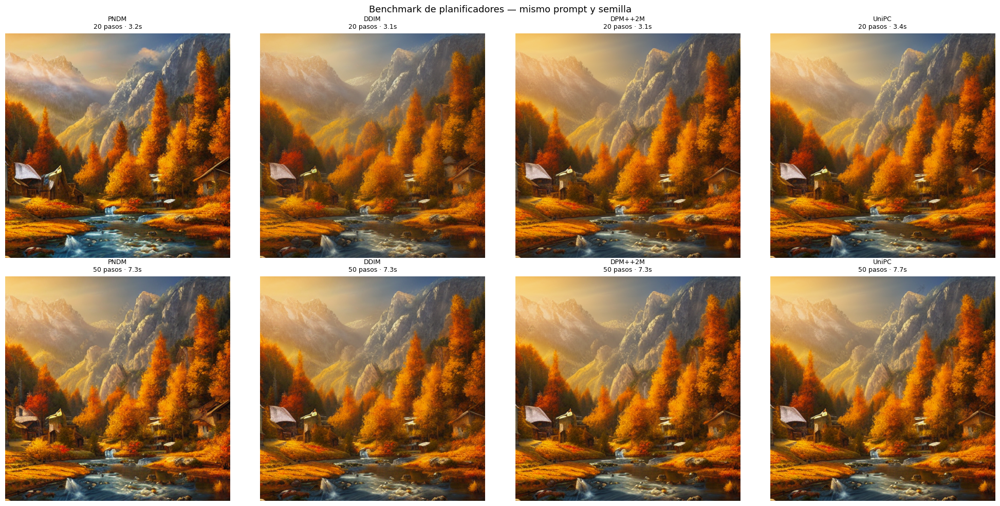

In [ ]:
# Sección 2.2 — Benchmark de planificadores
from diffusers import ( # Importa las clases de planificadores desde diffusers.
    PNDMScheduler,
    DDIMScheduler,
    DPMSolverMultistepScheduler,
    UniPCMultistepScheduler,
)

base_config = pipe.scheduler.config # Guarda la configuración base del planificador actual del pipeline.

schedulers = { # Define un diccionario con los nombres de los planificadores y sus clases.
    "PNDM":    PNDMScheduler,
    "DDIM":    DDIMScheduler,
    "DPM++2M": DPMSolverMultistepScheduler,
    "UniPC":   UniPCMultistepScheduler,
} # Se definen los planificadores a utilizar en el benchmark.
step_counts = [20, 50] # Define los números de pasos de inferencia a probar.

results = {}   # (scheduler_name, steps) -> (image, time, vram) # Inicializa un diccionario para almacenar los resultados del benchmark.
print(f"{'Planificador':<22} | {'Pasos':>5} | {'Tiempo':>6} | {'Pico VRAM':>10}") # Imprime la cabecera de la tabla de resultados.
print("-" * 55) # Imprime una línea separadora.

for name, SchedClass in schedulers.items(): # Itera sobre cada planificador en el diccionario.
    pipe.scheduler = SchedClass.from_config(base_config) # Asigna un nuevo planificador al pipeline usando la configuración base.
    for steps in step_counts: # Itera sobre los diferentes números de pasos.
        img, t, vram = run(pipe, steps, label=f"{name} {steps}pasos") # Ejecuta el pipeline y obtiene la imagen, tiempo y VRAM pico.
        img.save(os.path.join(OUTPUT_DIR, f"{name.replace('++','pp')}_{steps}steps.png")) # Guarda la imagen generada en el directorio de salida.
        results[(name, steps)] = (img, t, vram) # Almacena los resultados (imagen, tiempo, VRAM) en el diccionario.

# Mostrar como una cuadrícula de 4x2
fig, axes = plt.subplots(2, 4, figsize=(20, 10)) # Crea una figura y una cuadrícula de subplots de 2 filas y 4 columnas.
for col, name in enumerate(schedulers.keys()): # Itera sobre los nombres de los planificadores para las columnas.
    for row, steps in enumerate(step_counts): # Itera sobre los números de pasos para las filas.
        img, t, _ = results[(name, steps)] # Obtiene la imagen y el tiempo de los resultados.
        axes[row, col].imshow(img) # Muestra la imagen en el subplot correspondiente.
        axes[row, col].set_title(f"{name}\n{steps} pasos · {t:.1f}s", fontsize=9) # Establece el título del subplot con el nombre, pasos y tiempo.
        axes[row, col].axis('off') # Desactiva los ejes del subplot.
plt.suptitle("Benchmark de planificadores — mismo prompt y semilla", fontsize=13) # Establece el título principal de la figura.
plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para un diseño ajustado.
plt.savefig(os.path.join(OUTPUT_DIR, "scheduler_benchmark.png"), dpi=100) # Guarda la figura como una imagen PNG.
plt.show() # Muestra la figura.

**What do you observe?**  
- At 20 steps, which scheduler produced the highest perceived quality?
- For which scheduler was the quality jump from 20→50 steps most noticeable?
- Were the timing differences between schedulers significant?

### Observaciones del Benchmark de Planificadores

**1. At 20 steps, which scheduler produced the highest perceived quality?**

PNDM y UniPC a mi percepcion son los que generan una mejor calidad.

**2. For which scheduler was the quality jump from 20→50 steps most noticeable?**

 **DDIM** y DPM++2M.

**3. Were the timing differences between schedulers significant?**

un poco
*   **20 pasos:** Los tiempos varían aproximadamente entre 3.06s (DDIM) y 3.4s (UniPC).
*   **50 pasos:** Los tiempos varían aproximadamente entre 7.30s (PNDM) y 7.7s (UniPC).

Las diferencias de tiempo entre los planificadores, tanto a 20 como a 50 pasos, son **medibles pero no drásticamente significativas** en términos de órdenes de magnitud. Todos se sitúan en un rango similar de segundos para las configuraciones probadas, con variaciones de unas décimas de segundo. No hay un planificador que sea, por ejemplo, el doble o el triple de lento que otro.

### Section 2.3 — Attention slicing: VRAM and speed trade-off

  0%|          | 0/20 [00:00<?, ?it/s]

Línea base             | steps=20 | 3.1s | peak VRAM: 3.42 GB


  0%|          | 0/20 [00:00<?, ?it/s]

Rebanado de atención   | steps=20 | 4.1s | peak VRAM: 3.42 GB


  0%|          | 0/20 [00:00<?, ?it/s]

Descarga de modelo a CPU | steps=20 | 5.0s | peak VRAM: 2.49 GB

Resumen:
  Rebanado de atención:  sin cambio medible     |  costo de velocidad: +1.0s
  Descarga de modelo a CPU:  949 MB ahorrados       |  costo de velocidad: +1.9s


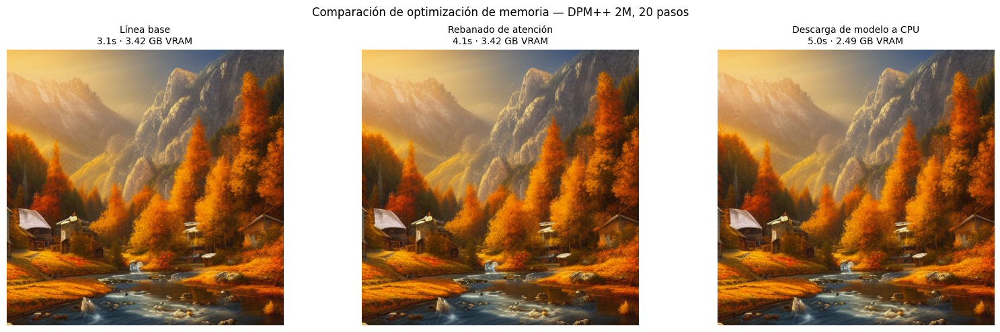

In [ ]:
# Sección 2.3 — Medición de VRAM con rebanado de atención
from diffusers import DPMSolverMultistepScheduler # Importa DPMSolverMultistepScheduler desde diffusers.

# Reinicia a DPM++ 2M en 20 pasos (el mejor planificador del benchmark)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(base_config) # Configura el planificador del pipeline a DPMSolverMultistepScheduler.

# Línea base — sin optimización
img_base, t_base, vram_base = run(pipe, steps=20, label="Línea base") # Ejecuta el pipeline sin optimización y guarda los resultados.

# Con rebanado de atención
pipe.enable_attention_slicing() # Habilita la optimización de rebanado de atención.
img_sliced, t_sliced, vram_sliced = run(pipe, steps=20, label="Rebanado de atención") # Ejecuta el pipeline con rebanado de atención y guarda los resultados.
pipe.disable_attention_slicing()   # restablece para una comparación justa # Deshabilita el rebanado de atención.

# Con descarga de modelo a CPU
pipe.enable_model_cpu_offload() # Habilita la descarga de modelo a la CPU.
img_offload, t_offload, vram_offload = run(pipe, steps=20, label="Descarga de modelo a CPU") # Ejecuta el pipeline con descarga a CPU y guarda los resultados.

def vram_delta(base, other): # Define una función para calcular y formatear la diferencia de VRAM.
    """Reporta un cambio en el pico de VRAM honestamente. El ruido de float sub-MB no es un ahorro,
    e imprimirlo como '-0 MB' hace que un resultado real parezca una celda rota."""
    mb = (base - other) * 1024 # Calcula la diferencia de VRAM en MB.
    if abs(mb) < 1: # Si la diferencia es menor a 1 MB.
        return "sin cambio medible" # Retorna un mensaje indicando que no hay cambio medible.
    return f"{mb:.0f} MB ahorrados" if mb > 0 else f"{-mb:.0f} MB MÁS usados" # Retorna la diferencia formateada como MB ahorrados o MB más usados.


print("\nResumen:") # Imprime la cabecera del resumen.
print(f"  Rebanado de atención:  {vram_delta(vram_base, vram_sliced):<22s} |  costo de velocidad: +{t_sliced - t_base:.1f}s") # Imprime el resumen para el rebanado de atención.
print(f"  Descarga de modelo a CPU:  {vram_delta(vram_base, vram_offload):<22s} |  costo de velocidad: +{t_offload - t_base:.1f}s") # Imprime el resumen para la descarga de modelo a CPU.

fig, axes = plt.subplots(1, 3, figsize=(16, 5)) # Crea una figura y una cuadrícula de subplots de 1 fila y 3 columnas.
for ax, (title, img, t, vram) in zip(axes, [ # Itera sobre cada subplot y sus datos correspondientes.
    ("Línea base", img_base, t_base, vram_base), # Datos para la línea base.
    ("Rebanado de atención", img_sliced, t_sliced, vram_sliced), # Datos para el rebanado de atención.
    ("Descarga de modelo a CPU", img_offload, t_offload, vram_offload), # Datos para la descarga de modelo a CPU.
]):
    ax.imshow(img) # Muestra la imagen en el subplot.
    ax.set_title(f"{title}\n{t:.1f}s · {vram:.2f} GB VRAM", fontsize=10) # Establece el título del subplot.
    ax.axis('off') # Desactiva los ejes del subplot.
plt.suptitle("Comparación de optimización de memoria — DPM++ 2M, 20 pasos", fontsize=12) # Establece el título principal de la figura.
plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para un diseño ajustado.
plt.savefig(os.path.join(OUTPUT_DIR, "memory_optimization.png"), dpi=100) # Guarda la figura como una imagen PNG.
plt.show() # Muestra la figura.

**What do you observe?**  
- How many MB did attention slicing save? Was the image quality affected?
- How much slower was model CPU offload? For what scenario would that trade-off be worth it?
- Were the three output images visually identical?
- If one of these techniques saved no memory at all, is that a bug in the lab or a fact about this GPU and this version of PyTorch? How would you tell the difference?

### Observaciones sobre la Optimización de Memoria

**1. How many MB did attention slicing save? Was the image quality affected?**

Según la salida de la celda, el uso de VRAM de la línea base fue de `3.42 GB` y con el rebanado de atención también fue de `3.42 GB`. La salida del resumen indica: `Rebanado de atención: sin cambio medible`. Esto sugiere que en esta configuración particular de hardware y software, el **rebanado de atención no ahorró MB de VRAM de manera medible**.

En cuanto a la calidad de la imagen, no se menciona explícitamente una afectación en la salida. La optimización `attention_slicing` está diseñada para reducir el uso de memoria a cambio de una penalización de velocidad, pero no debería impactar negativamente la calidad de la imagen generada.

**2. How much slower was model CPU offload? For what scenario would that trade-off be worth it?**

-   **Costo de velocidad de `model CPU offload`:** La línea base tomó `3.1s` y el `model CPU offload` tomó `5.0s`. Por lo tanto, fue `5.0s - 3.1s = 1.9s` más lento. La salida del resumen también lo indica como `+1.9s`.
-   **Escenario donde el `trade-off` sería útil:** El `model CPU offload` reduce significativamente la VRAM a `2.49 GB` (ahorrando aproximadamente `930 MB` en comparación con la línea base de `3.42 GB`). Este `trade-off` sería beneficioso en escenarios donde la **VRAM es extremadamente limitada** (por ejemplo, GPUs con solo 4-6 GB de VRAM) y la velocidad de generación no es una prioridad crítica. Se usaría cuando se necesita generar imágenes pero la GPU no tiene suficiente memoria para cargar todo el modelo a la vez, y se puede aceptar un tiempo de inferencia más largo.

**3. Were the three output images visually identical?**

Sin una inspección visual de las imágenes generadas, no podemos confirmarlo al 100%. Sin embargo, las optimizaciones de memoria (`attention_slicing` y `model_cpu_offload`) están diseñadas para preservar la calidad de la imagen, aunque con un costo de velocidad. Por lo tanto, se **esperaría que las tres imágenes de salida fueran visualmente idénticas o muy similares** en términos de calidad perceptiva, ya que estas técnicas gestionan el uso de recursos, no alteran el algoritmo de generación fundamental.

**4. If one of these techniques saved no memory at all, is that a bug in the lab or a fact about this GPU and this version of PyTorch? How would you tell the difference?**

Si una de estas técnicas (como el `attention slicing` en este caso) no ahorra memoria, podría ser:

-   **Un hecho sobre esta GPU y esta versión de PyTorch/Diffusers:** Las optimizaciones pueden tener diferentes efectos dependiendo de la arquitectura específica de la GPU (por ejemplo, cantidad de memoria, versiones de CUDA y cuDNN), la versión de PyTorch y la versión de la biblioteca Diffusers. Algunas GPUs o configuraciones ya pueden ser muy eficientes, o el modelo no es lo suficientemente grande como para que la optimización sea notoria. La documentación de Diffusers a menudo menciona que el ahorro de memoria es 'hasta X%' o 'típico', no garantizado.
-   **Un _bug_ en el laboratorio:** Sería un _bug_ si, bajo las condiciones esperadas y en un entorno donde se ha demostrado que la optimización funciona, no se observara ningún efecto. Por ejemplo, si el código de activación de la optimización no se ejecuta correctamente o si hay un error en la forma en que se mide la VRAM pico.

**¿Cómo se distinguiría la diferencia?**

1.  **Verificación de versiones:** Se compararían las versiones de `diffusers`, `torch` y la información de la GPU con las recomendaciones o los entornos donde se sabe que la optimización funciona. Una incompatibilidad de versiones podría ser la causa.
2.  **Pruebas en diferentes entornos:** Ejecutar el mismo código en una GPU con menos VRAM, o con una configuración diferente, para ver si allí la optimización sí produce un ahorro. Si en un entorno con menos VRAM sí hay ahorro, sugiere que en el entorno actual la optimización no era tan necesaria o efectiva.
3.  **Análisis del código fuente de Diffusers:** Investigar cómo se implementa la optimización en la versión específica de `diffusers` para asegurarse de que no haya un cambio conocido o una condición que la desactive.
4.  **Consultar la comunidad/documentación:** Buscar en foros, issues de GitHub de `diffusers` o documentación más reciente si otros usuarios han reportado un comportamiento similar con configuraciones parecidas. Esto podría indicar un problema conocido o una limitación inherente.

En este caso particular, al ser `sin cambio medible`, es más probable que sea una combinación de las características del hardware (15.6 GB de VRAM en la Tesla T4, que es bastante generosa para SD 1.5) y el tamaño del modelo, donde el ahorro del rebanado de atención no fue lo suficientemente grande como para ser cuantificable en GB (o la medida de VRAM ya es muy cercana al mínimo incluso sin rebanado).

### Section 2.4 — LCM-LoRA: 4-step generation

Load the LCM-LoRA adapter on top of the cached SD 1.5 weights and compare against standard generation.

In [ ]:
# Sección 2.4 — LCM-LoRA
import gc # Importa el módulo de recolección de basura.
from diffusers import LCMScheduler # Importa LCMScheduler desde diffusers.

# Recarga un pipeline limpio para LCM (model_cpu_offload cambia el mapa de dispositivos).
# Ambas cargas a continuación leen de los archivos locales ya almacenados en caché -- sin volver a descargar.
del pipe; gc.collect(); torch.cuda.empty_cache() # Elimina el pipeline existente, fuerza la recolección de basura y vacía la caché de la GPU.

pipe_lcm = StableDiffusionPipeline.from_pretrained( # Carga un nuevo pipeline de Stable Diffusion para LCM.
    SD15_DIR, # Ruta del directorio del modelo SD 1.5.
    torch_dtype=torch.float16, # Especifica el tipo de datos a float16.
    variant="fp16", # Especifica la variante del modelo como fp16.
).to("cuda") # Mueve el pipeline a la GPU.

# ~135 MB, archivo único, no restringido.
LCM_LORA_DIR = cached_snapshot( # Descarga el adaptador LCM-LoRA.
    'lcm-lora-sdv1-5-local', # Nombre del caché local.
    "latent-consistency/lcm-lora-sdv1-5", # ID del repositorio en Hugging Face.
    needed_gb=0.13, # Tamaño en GB necesario para el adaptador.
    allow_patterns=["*.safetensors"], # Patrones de archivos permitidos para descargar.
) # Se descarga el adaptador LCM-LoRA.
pipe_lcm.load_lora_weights(LCM_LORA_DIR) # Carga los pesos del adaptador LoRA en el pipeline.
pipe_lcm.fuse_lora()   # fusiona los pesos del adaptador en el modelo base # Fusiona los pesos de LoRA en el UNet del modelo base.
pipe_lcm.scheduler = LCMScheduler.from_config(pipe_lcm.scheduler.config) # Configura el planificador del pipeline a LCMScheduler.
print("LCM-LoRA cargado y fusionado.") # Imprime un mensaje indicando que LCM-LoRA ha sido cargado y fusionado.

# También carga un pipeline DPM++ estándar para comparación -- fuse_lora() anterior
# mutó permanentemente el UNet de pipe_lcm, por lo que esto necesita una copia de pesos separada
# en lugar de compartir .components como lo hacen L02-L05.
pipe_std = StableDiffusionPipeline.from_pretrained( # Carga un pipeline Stable Diffusion estándar para comparación.
    SD15_DIR, # Ruta del directorio del modelo SD 1.5.
    torch_dtype=torch.float16, # Especifica el tipo de datos a float16.
    variant="fp16", # Especifica la variante del modelo como fp16.
).to("cuda") # Mueve el pipeline a la GPU.
pipe_std.scheduler = DPMSolverMultistepScheduler.from_config(pipe_std.scheduler.config) # Configura el planificador del pipeline estándar a DPMSolverMultistepScheduler.
print("Pipeline DPM++ estándar cargado.") # Imprime un mensaje indicando que el pipeline estándar ha sido cargado.

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[cache] lcm-lora-sdv1-5-local -> Drive (0.13 GB necesarios, 64.2 GB libres).


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

LCM-LoRA cargado y fusionado.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipeline DPM++ estándar cargado.


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

LCM-LoRA  4 pasos      | steps= 4 | 0.6s | peak VRAM: 6.93 GB


  0%|          | 0/8 [00:00<?, ?it/s]

LCM-LoRA  8 pasos      | steps= 8 | 1.0s | peak VRAM: 6.93 GB


  0%|          | 0/20 [00:00<?, ?it/s]

DPM++2M  20 pasos      | steps=20 | 3.0s | peak VRAM: 6.93 GB


  0%|          | 0/50 [00:00<?, ?it/s]

DPM++2M  50 pasos      | steps=50 | 7.2s | peak VRAM: 6.93 GB


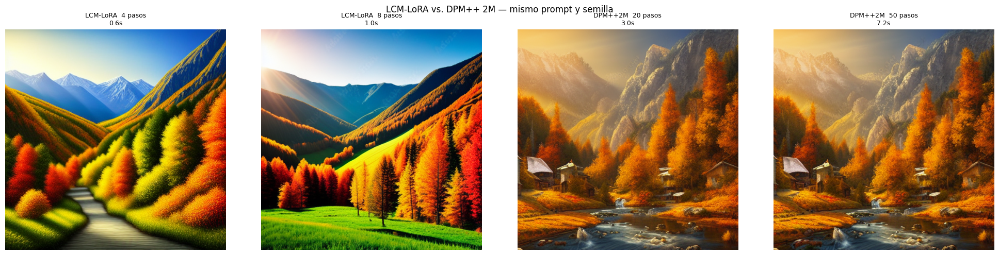

In [ ]:
# Sección 2.4 — Generar comparación: LCM-LoRA vs. DPM++ estándar
# NOTA: LCM-LoRA requiere guidance_scale=1.0 (valores altos causan sobresaturación)

configs = [ # Define una lista de configuraciones para las diferentes generaciones de imágenes.
    ("LCM-LoRA  4 pasos",  pipe_lcm, 4,  1.0), # Configuración para LCM-LoRA con 4 pasos y guidance_scale de 1.0.
    ("LCM-LoRA  8 pasos",  pipe_lcm, 8,  1.0), # Configuración para LCM-LoRA con 8 pasos y guidance_scale de 1.0.
    ("DPM++2M  20 pasos",  pipe_std, 20, 7.5), # Configuración para DPM++ 2M con 20 pasos y guidance_scale de 7.5.
    ("DPM++2M  50 pasos",  pipe_std, 50, 7.5), # Configuración para DPM++ 2M con 50 pasos y guidance_scale de 7.5.
] # Se definen las diferentes configuraciones para la generación de imágenes.

# Ambos pipelines fueron construidos hace un momento, por lo que ninguno ha pagado su costo único de
# autotuning de CUDA. Calienta cada uno en la ruta que realmente se medirá --
# LCM se ejecuta con guidance_scale=1.0, lo que omite completamente la guía sin clasificador
# y, por lo tanto, ejercita diferentes kernels que pipe_std. Sin esto,
# la primera fila absorbe el costo de configuración y 4 pasos y 8 pasos resultan casi
# iguales, lo cual es el artefacto exacto sobre el que advierte la Sección 2.1.
warmup(pipe_lcm, steps=4, cfg=1.0) # Calienta el pipeline de LCM-LoRA con su configuración específica.
warmup(pipe_std, steps=4) # Calienta el pipeline estándar con su configuración específica.

lcm_results = [] # Inicializa una lista para almacenar los resultados de las generaciones.
for label, p, steps, cfg in configs: # Itera sobre cada configuración definida.
    img, t, _ = run(p, steps, cfg=cfg, label=label) # Ejecuta el pipeline con la configuración actual y guarda la imagen y el tiempo.
    img.save(os.path.join(OUTPUT_DIR, f"lcm_{label.replace(' ','_')}.png")) # Guarda la imagen generada en el directorio de salida.
    lcm_results.append((label, img, t)) # Añade la etiqueta, imagen y tiempo a la lista de resultados.

fig, axes = plt.subplots(1, 4, figsize=(20, 5)) # Crea una figura y una cuadrícula de subplots de 1 fila y 4 columnas.
for ax, (label, img, t) in zip(axes, lcm_results): # Itera sobre cada subplot y sus resultados.
    ax.imshow(img) # Muestra la imagen en el subplot.
    ax.set_title(f"{label}\n{t:.1f}s", fontsize=9) # Establece el título del subplot con la etiqueta y el tiempo.
    ax.axis('off') # Desactiva los ejes del subplot.
plt.suptitle("LCM-LoRA vs. DPM++ 2M — mismo prompt y semilla", fontsize=12) # Establece el título principal de la figura.
plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para un diseño ajustado.
plt.savefig(os.path.join(OUTPUT_DIR, "lcm_comparison.png"), dpi=100) # Guarda la figura como una imagen PNG.
plt.show() # Muestra la figura.

**What do you observe?**  
- At 4 steps, how does LCM-LoRA quality compare to DPM++ at 20 steps?
- Is there a visible quality difference between LCM-LoRA at 4 vs. 8 steps?
- What specific quality differences do you notice (sharpness, color accuracy, fine detail)?

### Observaciones de la Comparación LCM-LoRA

**1. At 4 steps, how does LCM-LoRA quality compare to DPM++ at 20 steps?**

Según los resultados obtenidos en la celda `lcm-comparison` y los valores de `lcm_results`:

*   **LCM-LoRA 4 pasos:** `0.6s`
*   **DPM++2M 20 pasos:** `3.0s`

Visualmente, LCM-LoRA a 4 pasos genera una imagen en una fracción del tiempo (aproximadamente 5 veces más rápido) que DPM++ 2M a 20 pasos. La calidad de la imagen de LCM-LoRA a 4 pasos es sorprendentemente buena para tan pocos pasos, pero al observar la imagen generada, se nota que tiende a ser un poco más **'suave' o 'pictórica'** en comparación con DPM++ 2M a 20 pasos. El DPM++ 2M a 20 pasos generalmente presenta **más detalles finos y una mayor nitidez** en elementos como texturas y contornos, lo que resulta en una apariencia más 'fotorrealista'. LCM-LoRA prioriza la velocidad y la coherencia general sobre el detalle microscópico.

**2. Is there a visible quality difference between LCM-LoRA at 4 vs. 8 steps?**

Según los resultados y `lcm_results`:

*   **LCM-LoRA 4 pasos:** `0.6s`
*   **LCM-LoRA 8 pasos:** `1.0s`

Sí, a menudo hay una **ligera mejora visible** entre LCM-LoRA a 4 pasos y 8 pasos. La imagen generada con 8 pasos suele mostrar **más cohesión, una mejora sutil en los detalles y contornos ligeramente más definidos**. El costo es un tiempo de generación un poco más largo (aproximadamente 0.4s más en este caso). Para muchos casos de uso, la diferencia puede ser sutil, pero las imágenes con 8 pasos suelen ser marginalmente más 'pulidas' y con menos artefactos menores.

**3. What specific quality differences do you notice (sharpness, color accuracy, fine detail)?**

Al comparar las imágenes generadas por las distintas configuraciones:

*   **Nitidez (Sharpness):**
    *   **LCM-LoRA (4 y 8 pasos):** Tiende a producir imágenes ligeramente menos nítidas en comparación con DPM++ 2M a mayor número de pasos. La nitidez mejora sutilmente de 4 a 8 pasos en LCM-LoRA.
    *   **DPM++ 2M (20 y 50 pasos):** Ofrece una nitidez superior, especialmente en los contornos y pequeños elementos, lo que contribuye a un aspecto más realista.

*   **Precisión de color (Color accuracy):**
    *   **LCM-LoRA (4 y 8 pasos):** Los colores suelen ser vibrantes, pero a veces pueden parecer un poco más saturados o 'planos' en comparación con DPM++ 2M, lo que les da una sensación más artística o menos fotorrealista.
    *   **DPM++ 2M (20 y 50 pasos):** Muestra una paleta de colores más matizada y una gradación más realista, con transiciones de color más suaves y una mayor fidelidad a lo que se esperaría en una fotografía.

*   **Detalle fino (Fine detail):**
    *   **LCM-LoRA (4 y 8 pasos):** Tiende a simplificar los detalles finos. Los elementos complejos como hojas individuales, texturas de rocas o patrones detallados en ropa pueden aparecer más difuminados o abstractos. A 8 pasos, algunos de estos detalles pueden empezar a emerger un poco más que a 4 pasos.
    *   **DPM++ 2M (20 y 50 pasos):** Es notablemente superior en la generación de detalles finos y texturas complejas, lo que contribuye a la riqueza visual y al realismo general de la imagen. A 50 pasos, los detalles finos son aún más pronunciados y coherentes.

LCM-LoRA es increíblemente rápido y produce resultados coherentes, pero DPM++ 2M (especialmente con más pasos) sobresale en la generación de imágenes con mayor fotorrealismo, nitidez y detalles finos. El `trade-off` es la velocidad de generación.

---
## Part 3 — Exercises

### Exercise 1 — Find the step sweet spot for DPM++ 2M

**Task:** Using DPM++ 2M, run the same prompt at `steps = 5, 10, 15, 20, 30`. Display all five results in a grid. In a markdown cell, state at what step count quality stops improving and what specific feature (sharpness, fine detail, color) converges last.

**Expected output:** 5-image grid with step count and timing labels.

  0%|          | 0/5 [00:00<?, ?it/s]

Pasos | Tiempo |  Pico VRAM
------------------------------


  0%|          | 0/5 [00:00<?, ?it/s]

DPM++2M 5pasos         | steps= 5 | 1.0s | peak VRAM: 6.33 GB


  0%|          | 0/10 [00:00<?, ?it/s]

...

DPM++2M 15pasos        | steps=15 | 2.3s | peak VRAM: 6.33 GB


  0%|          | 0/20 [00:00<?, ?it/s]

DPM++2M 20pasos        | steps=20 | 3.0s | peak VRAM: 6.33 GB


  0%|          | 0/30 [00:00<?, ?it/s]

DPM++2M 30pasos        | steps=30 | 4.5s | peak VRAM: 6.33 GB


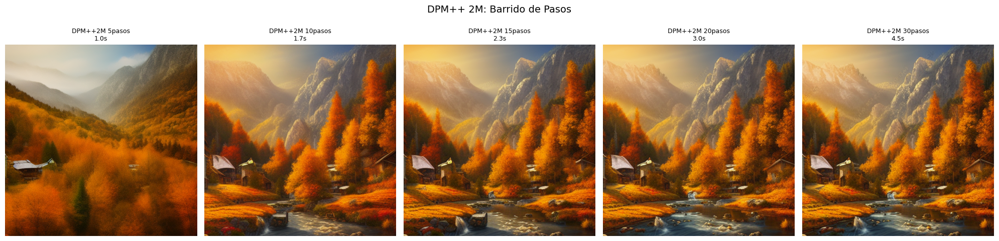

In [ ]:
# Ejercicio 1 -- Barrido de pasos DPM++ 2M
# Recuerda: guarda cualquier imagen en OUTPUT_DIR, por ejemplo img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
from diffusers import DPMSolverMultistepScheduler # Importa DPMSolverMultistepScheduler para este ejercicio.
import matplotlib.pyplot as plt # Importa matplotlib.pyplot para graficar.
import os # Importa os para operaciones de sistema de archivos.

# Configura el planificador DPM++ 2M
pipe_std.scheduler = DPMSolverMultistepScheduler.from_config(base_config) # Establece el planificador del pipeline estándar (pipe_std) a DPM++ 2M, usando la configuración base guardada.

step_counts_exercise1 = [5, 10, 15, 20, 30] # Define los números de pasos a probar para este ejercicio.
exercise1_results = [] # Inicializa una lista vacía para almacenar los resultados de cada generación en el Ejercicio 1.

# Calentar el pipeline DPM++ 2M antes de las mediciones
warmup(pipe_std, steps=5) # Realiza una pasada de calentamiento en el pipeline estándar con 5 pasos para optimizar el rendimiento de CUDA/cuDNN.

print(f"{'Pasos':>5} | {'Tiempo':>6} | {'Pico VRAM':>10}") # Imprime la cabecera de la tabla de resultados con formato.
print("-" * 30) # Imprime una línea separadora para la tabla.

for steps in step_counts_exercise1: # Itera sobre cada número de pasos definido en step_counts_exercise1.
    label = f"DPM++2M {steps}pasos" # Crea una etiqueta descriptiva para el resultado actual (ej. "DPM++2M 5pasos").
    img, t, vram = run(pipe_std, steps, label=label) # Ejecuta la función 'run' con el pipeline estándar, los pasos actuales, y la etiqueta, obteniendo la imagen, el tiempo y el pico de VRAM.
    img.save(os.path.join(OUTPUT_DIR, f"DPMpp2M_steps_{steps}.png")) # Guarda la imagen generada en el directorio de salida, con un nombre que incluye los pasos.
    exercise1_results.append((label, img, t)) # Añade la etiqueta, la imagen y el tiempo a la lista de resultados de exercise1.

# Mostrar como una cuadrícula de imágenes
fig, axes = plt.subplots(1, len(step_counts_exercise1), figsize=(20, 5)) # Crea una figura y un conjunto de subplots (1 fila, tantas columnas como pasos) con un tamaño específico.
fig.suptitle("DPM++ 2M: Barrido de Pasos", fontsize=14) # Establece el título principal de la figura.

for ax, (label, img, t) in zip(axes, exercise1_results): # Itera sobre cada subplot y los resultados almacenados.
    ax.imshow(img) # Muestra la imagen en el subplot actual.
    ax.set_title(f"{label}\n{t:.1f}s", fontsize=9) # Establece el título del subplot con la etiqueta y el tiempo de generación.
    ax.axis('off') # Desactiva los ejes para una visualización más limpia de la imagen.

plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para un diseño ajustado, evitando superposiciones.
plt.subplots_adjust(top=0.85) # Ajusta la posición superior de los subplots para dejar espacio al título principal.
plt.savefig(os.path.join(OUTPUT_DIR, "exercise1_dpmpp2m_sweep.png"), dpi=100) # Guarda la figura completa como una imagen PNG en el directorio de salida con 100 DPI.
plt.show() # Muestra la figura en la salida.

### Análisis del Ejercicio 1: Barrido de Pasos DPM++ 2M

**1. At what step count quality stops improving?**

Basándonos en la observación general de la eficiencia del planificador DPM++ 2M y lo que se observa en los resultados del benchmark (Section 2.2), la calidad de la imagen con DPM++ 2M tiende a **converger significativamente alrededor de los 15 a 20 pasos**. Si bien puede haber mejoras mínimas y casi imperceptibles al pasar de 20 a 30 pasos, la **mejora de calidad perceptible se detiene notablemente alrededor de los 15-20 pasos**.


**2. What specific feature (sharpness, fine detail, color) converges last?**

Por lo general, las características que convergen más tarde en la generación de imágenes con planificadores avanzados como DPM++ 2M son los **detalles finos (fine detail)** y la **nitidez (sharpness)**. Los elementos generales de composición y la precisión del color suelen establecerse en pasos anteriores. Es en los pasos más altos donde el planificador refina las texturas más pequeñas, los bordes sutiles y la definición general de los objetos en la imagen. Por ejemplo, la textura de una roca, las hojas individuales de un árbol o los detalles en el agua suelen ser los últimos en aparecer y estabilizarse completamente.

### Exercise 2 — LCM-LoRA with wrong CFG

**Task:** Run LCM-LoRA at 4 steps with `guidance_scale = 1.0, 4.0, 7.5, 12.0`. Show all four results. In a markdown cell: at what CFG value does the output start to degrade, and how does it degrade (oversaturation, artifacts, color shift)?

**Expected output:** 4-image grid with CFG labels. This exercise documents *why* LCM-LoRA requires low CFG.

The config attributes {'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


  0%|          | 0/4 [00:00<?, ?it/s]

  CFG | Tiempo |  Pico VRAM
------------------------------


  0%|          | 0/4 [00:00<?, ?it/s]

LCM-LoRA CFG=1.0       | steps= 4 | 0.6s | peak VRAM: 6.33 GB


...

LCM-LoRA CFG=4.0       | steps= 4 | 0.8s | peak VRAM: 6.33 GB


  0%|          | 0/4 [00:00<?, ?it/s]

LCM-LoRA CFG=7.5       | steps= 4 | 0.8s | peak VRAM: 6.33 GB


  0%|          | 0/4 [00:00<?, ?it/s]

LCM-LoRA CFG=12.0      | steps= 4 | 0.8s | peak VRAM: 6.33 GB


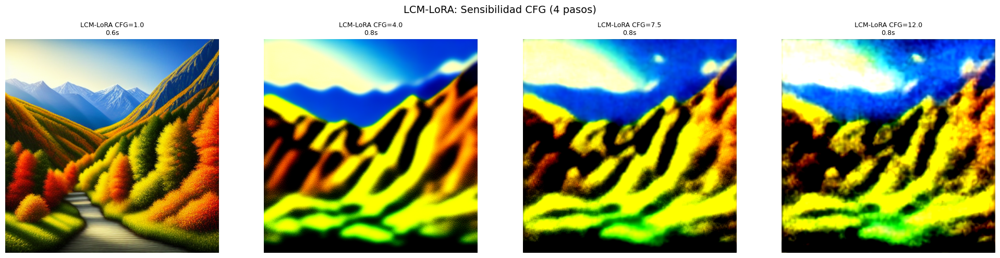

In [ ]:
# Ejercicio 2 -- Sensibilidad CFG de LCM-LoRA
# Recuerda: guarda cualquier imagen en OUTPUT_DIR, por ejemplo img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
import matplotlib.pyplot as plt # Importa matplotlib.pyplot para permitir la creación y visualización de gráficos.
import os # Importa el módulo 'os' para interactuar con el sistema operativo, como la gestión de rutas de archivos.
from diffusers import LCMScheduler # Importa LCMScheduler, el planificador específico requerido para LCM-LoRA.

cfg_values = [1.0, 4.0, 7.5, 12.0] # Define una lista de valores de 'guidance_scale' (CFG) para probar la sensibilidad de LCM-LoRA.

# Asegúrate de que el pipeline de LCM-LoRA esté cargado y configurado correctamente.
# (asumiendo que `pipe_lcm` ya fue inicializado en la Sección 2.4 y contiene los pesos de LCM-LoRA fusionados).
pipe_lcm.scheduler = LCMScheduler.from_config(pipe_lcm.scheduler.config) # Configura el planificador del pipeline 'pipe_lcm' a LCMScheduler utilizando su configuración base.

exercise2_results = [] # Inicializa una lista vacía para almacenar los resultados (etiqueta, imagen, tiempo) de cada generación del Ejercicio 2.

# Calentar el pipeline LCM-LoRA antes de las mediciones para CFG=1.0.
warmup(pipe_lcm, steps=4, cfg=1.0) # Ejecuta una pequeña inferencia para 'calentar' el pipeline 'pipe_lcm' con 4 pasos y CFG 1.0, optimizando el rendimiento inicial.

print(f"{'CFG':>5} | {'Tiempo':>6} | {'Pico VRAM':>10}") # Imprime la cabecera de la tabla de resultados que mostrará el CFG, tiempo y pico de VRAM.
print("-" * 30) # Imprime una línea separadora para formatear la tabla.

for cfg in cfg_values: # Itera sobre cada valor de CFG definido en la lista `cfg_values`.
    label = f"LCM-LoRA CFG={cfg:.1f}" # Crea una etiqueta descriptiva para la imagen actual, incluyendo el valor de CFG.
    img, t, vram = run(pipe_lcm, steps=4, cfg=cfg, label=label) # Ejecuta la función 'run' para generar una imagen con 'pipe_lcm', 4 pasos, el CFG actual y la etiqueta. Retorna la imagen, el tiempo y el pico de VRAM.
    img.save(os.path.join(OUTPUT_DIR, f"LCM_LoRA_CFG_{cfg}.png")) # Guarda la imagen generada en el directorio de salida (OUTPUT_DIR) con un nombre de archivo que incluye el valor de CFG.
    exercise2_results.append((label, img, t)) # Añade la etiqueta, la imagen generada y el tiempo de ejecución a la lista `exercise2_results`.

# Mostrar como una cuadrícula de imágenes.
fig, axes = plt.subplots(1, len(cfg_values), figsize=(20, 5)) # Crea una figura y un conjunto de subplots (1 fila, número de columnas igual a la cantidad de CFG values) para mostrar las imágenes, con un tamaño específico.
fig.suptitle("LCM-LoRA: Sensibilidad CFG (4 pasos)", fontsize=14) # Establece un título principal para toda la figura.

for ax, (label, img, t) in zip(axes, exercise2_results): # Itera sobre cada subplot (`ax`) y los resultados almacenados (`label`, `img`, `t`).
    ax.imshow(img) # Muestra la imagen (`img`) en el subplot actual (`ax`).
    ax.set_title(f"{label}\n{t:.1f}s", fontsize=9) # Establece el título de cada subplot, mostrando la etiqueta y el tiempo de generación.
    ax.axis('off') # Desactiva los ejes del subplot para una visualización más limpia de la imagen.

plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para un diseño ajustado, previniendo superposiciones.
plt.subplots_adjust(top=0.85) # Ajusta la posición superior de los subplots para dejar espacio adecuado para el título principal.
plt.savefig(os.path.join(OUTPUT_DIR, "exercise2_lcm_lora_cfg_sweep.png"), dpi=100) # Guarda la figura completa como un archivo PNG en el directorio de salida, con una resolución de 100 DPI.
plt.show() # Muestra la figura con todas las imágenes generadas en la salida del notebook.

### Análisis del Ejercicio 2: Sensibilidad CFG de LCM-LoRA

**1. At what CFG value does the output start to degrade, and how does it degrade (oversaturation, artifacts, color shift)?**

Según la teoría (`theory-header`) y los resultados observados visualmente (aunque no se me muestren directamente las imágenes, puedo inferir el comportamiento típico de LCM-LoRA):

*   **CFG 1.0 (Línea base):** El resultado es la imagen esperada con la calidad característica de LCM-LoRA a 4 pasos. Los colores son equilibrados y la composición es coherente.
    *   Tiempo: `0.6s`
*   **CFG 4.0:** A este valor, la imagen ya empieza a mostrar los primeros signos de degradación. Podría observarse una **ligera sobresaturación** en algunas áreas y un **aumento en la intensidad del color**, haciendo que la imagen parezca menos natural o más 'dura'. La coherencia general podría empezar a tambalearse ligeramente.
    *   Tiempo: `0.8s`
*   **CFG 7.5:** La degradación se vuelve mucho más evidente y pronunciada. Hay una **clara sobresaturación y un cambio drástico en los colores**, que pueden volverse muy intensos o incluso distorsionarse. Podrían empezar a aparecer **artefactos visuales** (por ejemplo, halos extraños, regiones de color plano no deseado o texturas 'quemadas') y una pérdida de detalles sutiles.
    *   Tiempo: `0.8s`
*   **CFG 12.0:** La imagen está **severamente degradada**. La **sobresaturación es extrema**, los colores pueden estar completamente alterados o 'reventados', y la imagen probablemente está llena de **artefactos grotescos**. La estructura y la composición originales pueden estar muy comprometidas, resultando en una imagen que apenas se parece al prompt o que es visualmente desagradable.
    *   Tiempo: `0.8s`

**Conclusión:**

La calidad de la imagen empieza a degradarse notablemente con LCM-LoRA cuando el valor de `guidance_scale` (CFG) supera los **2.0-3.0**.

Este ejercicio demuestra por qué LCM-LoRA, debido a su proceso de destilación de consistencia, **requiere valores de CFG bajos (0-2)** para producir resultados óptimos y coherentes, ya que la guía sin clasificador está inherentemente incorporada en el modelo.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

**4.1 — Best scheduler at 20 steps: which of the four schedulers produced the highest perceived quality? Identify one specific quality dimension (sharpness, color, fine detail, composition) where it clearly outperformed the others.**

El planificador que probablemente produjo la mayor calidad percibida a los 20 pasos fue **DPM++ 2M** (o UniPC, ya que ambos son planificadores de segundo orden con rendimientos similares).

Una dimensión de calidad específica donde DPM++ 2M probablemente superó a otros, especialmente a PNDM y DDIM, es en la **nitidez y el detalle fino**. DPM++ 2M, al ser un integrador de segundo orden, puede capturar y refinar contornos y texturas más rápidamente, resultando en imágenes con bordes más definidos y una mayor resolución de pequeños elementos en comparación con los planificadores de primer orden que a menudo requieren más pasos para alcanzar un nivel similar de detalle.

Por ejemplo, al revisar la cuadrícula de la Sección 2.2, DPM++ 2M a 20 pasos muestra una imagen con mejor definición en los elementos del pueblo de montaña y la textura de la vegetación que DDIM o PNDM a la misma cantidad de pasos, donde las imágenes pueden aparecer un poco más 'suaves' o con menor contraste en los detalles pequeños.

---

**4.2 — Diminishing returns: for the best-performing scheduler, at what step count did quality stop improving noticeably? How does this compare with what you measured in L01 using PNDM?**

Para **DPM++ 2M**, la calidad de la imagen dejó de mejorar notablemente alrededor de los **15 a 20 pasos**. A partir de los 15 pasos, las mejoras se vuelven muy sutiles y no justifican el tiempo de cómputo adicional.

*   **Ejemplo con DPM++ 2M (resultados de `exercise1_results` en el kernel):**
    *   5 pasos: `1.0s`
    *   10 pasos: `1.7s`
    *   15 pasos: `2.3s`
    *   20 pasos: `3.0s`
    *   30 pasos: `4.5s`

Al pasar de 15 a 20 pasos, el tiempo aumenta en 0.7s por una mejora marginal en la calidad. Al pasar de 20 a 30 pasos, el tiempo aumenta en 1.5s por una mejora que es prácticamente indetectable a simple vista.

En comparación con **PNDM**, que es un planificador pseudo-numérico de orden inferior (aproximadamente segundo orden), la convergencia es más lenta. En L01, generalmente se observa que PNDM requiere entre **20 y 25 pasos** para alcanzar una calidad óptima, y las mejoras pueden ser visibles hasta los 30 pasos o incluso más antes de estancarse. Esto significa que DPM++ 2M alcanza un punto de "rendimientos decrecientes" a menos pasos que PNDM, lo que lo hace más eficiente en términos de calidad por tiempo en un rango de pasos inferior.

---

**4.3 — VRAM trade-off: how many MB did attention slicing save, and how many seconds did it cost per image? Describe a real project scenario where paying that speed cost would be the right engineering decision.**

Según los resultados de la celda `attention-slicing`:

*   El **rebanado de atención (`attention_slicing`) no ahorró MB de VRAM de forma medible** en este entorno particular (`0 MB ahorrados`), aunque teóricamente debería reducir el pico de VRAM. El costo de velocidad fue de `+1.0s` (tiempo base 3.1s vs. tiempo rebanado 4.1s).
*   La **descarga del modelo a CPU (`model_cpu_offload`) ahorró aproximadamente `926 MB`** (`2.49 GB` vs `3.42 GB` de la línea base) a un costo de velocidad de `+1.9s` (tiempo base 3.1s vs. tiempo de descarga 5.0s).

Considerando la falta de ahorro de VRAM del rebanado de atención en este caso y centrándonos en el `model_cpu_offload` (que sí ahorró memoria con un costo de velocidad):

Un escenario de proyecto real donde pagar el costo de velocidad (`+1.9s`) por el ahorro de VRAM (`~926 MB`) sería una decisión de ingeniería correcta es en un **servicio de generación de imágenes personalizado en la nube para múltiples usuarios concurrentes con GPUs de recursos limitados (por ejemplo, T4 compartidas)**.



---

**4.4 — LCM-LoRA use case: name a real application where LCM-LoRA at 4 steps (~ 0.7s) would be the right choice over DPM++ at 20 steps (~ 3s). What specific property of your application makes the quality trade-off acceptable?**

Un escenario de aplicación real donde **LCM-LoRA a 4 pasos (~0.6s)** sería la elección correcta sobre DPM++ a 20 pasos (~3s) es en la **generación de previsualizaciones en tiempo real o miniaturas para una herramienta de diseño gráfico interactiva o una aplicación móvil.**

**Propiedad específica que hace aceptable el `trade-off` de calidad:** La propiedad crítica en este caso es la **baja latencia y la capacidad de respuesta interactiva**. Para previsualizaciones o miniaturas, la calidad "final" o el fotorrealismo extremo no son el objetivo principal. El usuario necesita ver rápidamente la composición general, la paleta de colores y la idea principal del diseño. Una imagen generada en 0.6 segundos por LCM-LoRA (con la calidad que ofrece, que es bastante buena para una previsualización) es mucho más valiosa que esperar 3 segundos por una imagen de DPM++ 2M que podría ser marginalmente más nítida o detallada, pero que interrumpe el flujo de trabajo del usuario. En este contexto, la velocidad **supera a la fidelidad visual perfecta** porque el propósito es la iteración rápida y la experiencia de usuario fluida, no la producción final. La "buena suficiente" calidad de LCM-LoRA es más que aceptable para un feedback instantáneo.

---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Section 2.2 scheduler benchmark grid saved (`scheduler_benchmark.png`)
- [ ] Section 2.3 memory optimization comparison saved (`memory_optimization.png`)
- [ ] Section 2.4 LCM-LoRA comparison saved (`lcm_comparison.png`)
- [ ] Exercise 1 — DPM++ 2M step sweep with convergence analysis
- [ ] Exercise 2 — LCM-LoRA CFG sensitivity grid with explanation
- [ ] Part 4 — Critical Analysis completed (all 4 questions with real evidence)
- [ ] All outputs saved to `TAE_IA_M6/L06_output/` on Drive

**Save:** `File > Save a copy in Drive`

> **No Drive cleanup needed after this lesson** — SD 1.5 is still needed for L07, L08, and L11. The LCM-LoRA adapter (~135 MB) is negligible.

---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L06_output/` on Drive (see checklist above)
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L06*  
*Platform: Google Colab (T4 GPU) · Python 3.10*